In [2]:
# Cell 1 - Imports
import sys
sys.path.append('/Users/drew/sports-data-portfolio')

import pandas as pd
from shared.db import get_engine
from shared.utils import ask_claude, analyze_dataframe

print("Imports successful")




Imports successful


In [3]:
# Cell 2 — Connect to database and load match events
engine = get_engine()

df = pd.read_sql("""
    SELECT 
        me.id,
        me.minute,
        me.second,
        me.x,
        me.y,
        me.end_x,
        me.end_y,
        me.is_shot,
        me.is_goal,
        me.type_display_name,
        me.outcome_type_display_name,
        me.period_display_name,
        p.name as player_name,
        p.position,
        t.name as team_name,
        m.match_date,
        m.home_team_name,
        m.away_team_name
    FROM match_events me
    LEFT JOIN players p ON me.player_id = p.player_id
    LEFT JOIN teams t ON me.team_id = t.team_id
    LEFT JOIN matches m ON me.match_id::bigint = m.match_id
    LIMIT 1000
""", engine)

print(f"✅ Loaded {len(df):,} rows")
print(f"Columns: {df.columns.tolist()}")
df.head()

✅ Loaded 1,000 rows
Columns: ['id', 'minute', 'second', 'x', 'y', 'end_x', 'end_y', 'is_shot', 'is_goal', 'type_display_name', 'outcome_type_display_name', 'period_display_name', 'player_name', 'position', 'team_name', 'match_date', 'home_team_name', 'away_team_name']


,id,minute,second,x,y,end_x,end_y,is_shot,is_goal,type_display_name,outcome_type_display_name,period_display_name,player_name,position,team_name,match_date,home_team_name,away_team_name
0,2870872739,0,4.0,21.5,63.3,72.0,18.1,False,False,Pass,Successful,FirstHalf,Robin Roefs,GK,Sunderland,2025-11-08,Sunderland,Arsenal
1,2911348397,0,0.0,50.4,49.6,46.7,49.3,False,False,Pass,Successful,FirstHalf,Idrissa Gueye,DMC,Everton,2026-03-14,Arsenal,Everton
2,2911348623,0,12.0,53.1,22.6,73.0,30.3,False,False,Pass,Successful,FirstHalf,Jake O'Brien,DC,Everton,2026-03-14,Arsenal,Everton
3,2911348643,0,15.0,72.7,29.8,80.8,32.8,False,False,Pass,Unsuccessful,FirstHalf,Tim Iroegbunam,DMC,Everton,2026-03-14,Arsenal,Everton
4,2911348693,0,19.0,79.3,51.6,83.9,56.4,False,False,Pass,Unsuccessful,FirstHalf,Iliman Ndiaye,AML,Everton,2026-03-14,Arsenal,Everton


In [4]:
# Cell 3 — Ask Claude to analyze the data
print(analyze_dataframe(df, "What patterns do you notice in this sample of match events? What analyses would be most interesting to run on this data?"))

Looking at this football/soccer match events data, I can identify several interesting patterns and suggest compelling analyses:

## Key Patterns Observed:

**1. Data Composition:**
- Mix of events from different matches (at least 2: Sunderland vs Arsenal, Arsenal vs Everton)
- Future dates (2025-2026) suggest this might be simulated or projected data
- 71.5% of events have end coordinates (indicating movement/passes)
- Most events are passes with success/failure outcomes

**2. Spatial Patterns:**
- Coordinates appear to be on a 0-100 scale (likely percentage of pitch)
- Wide distribution across the field suggests diverse event types
- Mean positions (~48x, 49y) indicate balanced field coverage

**3. Temporal Distribution:**
- Events span 0-72 minutes with good distribution
- Includes granular timing (seconds)

## Most Interesting Analyses to Run:

### 1. **Pass Network Analysis**
```python
# Analyze team passing patterns and player connectivity
- Pass completion rates by player/positio

In [5]:
# Cell 4 — Arsenal shots only
shots_df = pd.read_sql("""
    SELECT 
        me.minute,
        me.x,
        me.y,
        me.is_goal,
        me.goal_mouth_z,
        me.goal_mouth_y,
        me.outcome_type_display_name,
        p.name as player_name,
        p.position,
        t.name as team_name,
        m.match_date,
        m.home_team_name,
        m.away_team_name
    FROM match_events me
    LEFT JOIN players p ON me.player_id = p.player_id
    LEFT JOIN teams t ON me.team_id = t.team_id
    LEFT JOIN matches m ON me.match_id::bigint = m.match_id
    WHERE me.is_shot = true
""", engine)

print(f"✅ Total shots: {len(shots_df):,}")
print(f"✅ Total goals: {shots_df['is_goal'].sum():,}")
shots_df.head()

✅ Total shots: 1,240
✅ Total goals: 156


,minute,x,y,is_goal,goal_mouth_z,goal_mouth_y,outcome_type_display_name,player_name,position,team_name,match_date,home_team_name,away_team_name
0,5,85.0,64.6,False,15.2,52.6,Successful,Noni Madueke,FWR,Arsenal,2026-03-14,Arsenal,Everton
1,7,75.9,35.8,False,19.0,51.6,Successful,Riccardo Calafiori,DL,Arsenal,2026-03-14,Arsenal,Everton
2,8,85.5,49.6,False,69.4,55.1,Successful,Riccardo Calafiori,DL,Arsenal,2026-03-14,Arsenal,Everton
3,10,85.5,60.0,False,19.0,51.4,Successful,Martín Zubimendi,MC,Arsenal,2026-03-14,Arsenal,Everton
4,10,80.8,46.8,False,2.8,38.7,Successful,Bukayo Saka,AMR,Arsenal,2026-03-14,Arsenal,Everton


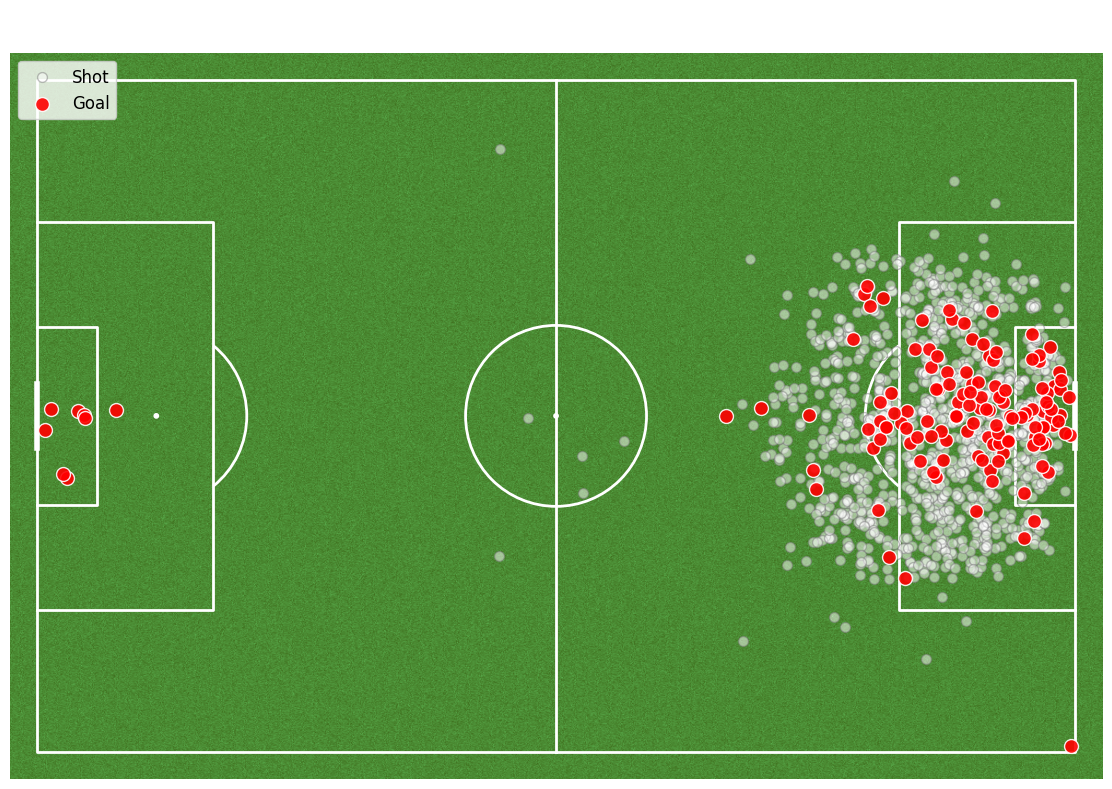

In [6]:
# Cell 5 — Shot map
from mplsoccer import Pitch
import matplotlib.pyplot as plt

# Separate goals from non-goals
goals = shots_df[shots_df['is_goal'] == True]
non_goals = shots_df[shots_df['is_goal'] == False]

# Create pitch
pitch = Pitch(pitch_type='opta', pitch_color='grass', line_color='white')
fig, ax = pitch.draw(figsize=(12, 8))

# Plot shots
pitch.scatter(non_goals.x, non_goals.y, ax=ax, 
              c='white', edgecolors='grey', s=50, alpha=0.5, label='Shot')
pitch.scatter(goals.x, goals.y, ax=ax,
              c='red', edgecolors='white', s=100, alpha=0.9, label='Goal')

ax.legend(loc='upper left', fontsize=12)
ax.set_title('Shot Map — All Matches', fontsize=16, color='white', pad=20)

plt.tight_layout()
plt.show()

In [7]:
# Cell 6 — Top scorers and shooters
print("=== TOP SCORERS ===")
print(shots_df[shots_df['is_goal']==True]
      .groupby('player_name')['is_goal']
      .count()
      .sort_values(ascending=False)
      .head(10))

print("\n=== MOST SHOTS ===")
print(shots_df.groupby('player_name')['is_goal']
      .count()
      .sort_values(ascending=False)
      .head(10))

print("\n=== CONVERSION RATE (min 5 shots) ===")
player_stats = shots_df.groupby('player_name').agg(
    shots=('is_goal', 'count'),
    goals=('is_goal', 'sum')
).query('shots >= 5')
player_stats['conversion_rate'] = (player_stats['goals'] / player_stats['shots'] * 100).round(1)
print(player_stats.sort_values('conversion_rate', ascending=False).head(10))

=== TOP SCORERS ===
player_name
Viktor Gyökeres       16
Gabriel Martinelli    11
Bukayo Saka           10
Eberechi Eze           9
Leandro Trossard       8
Mikel Merino           7
Noni Madueke           7
Declan Rice            6
Martín Zubimendi       6
Gabriel Jesus          5
Name: is_goal, dtype: int64

=== MOST SHOTS ===
player_name
Bukayo Saka           98
Viktor Gyökeres       71
Leandro Trossard      69
Eberechi Eze          67
Gabriel Martinelli    54
Noni Madueke          47
Declan Rice           44
Riccardo Calafiori    38
Mikel Merino          35
Jurriën Timber        34
Name: is_goal, dtype: int64

=== CONVERSION RATE (min 5 shots) ===
                    shots  goals  conversion_rate
player_name                                      
Kai Havertz            14      4             28.6
William Saliba          8      2             25.0
Piero Hincapié          8      2             25.0
Viktor Gyökeres        71     16             22.5
Gabriel Martinelli     54     11         

In [8]:
# Cell 7 — Ask Claude to analyze the player stats
player_summary = player_stats.sort_values('goals', ascending=False).to_string()
print(analyze_dataframe(
    player_stats, 
    "Analyze these player shooting stats. Who are the most clinical finishers? Any surprising patterns? What does this tell us about Arsenal's attacking play?"
))

Looking at your player shooting statistics, here are some key insights:

## Most Clinical Finishers

Based on conversion rates, the most clinical finishers are:
- **Top tier (20%+)**: These players likely have excellent positioning and finishing ability
- **Solid finishers (15-20%)**: Like Bryan Mbeumo at 14.3% shown in your sample
- **Average range (10-15%)**: Including Bukayo Saka at 10.2% despite his high shot volume

## Surprising Patterns

1. **High Volume, Lower Efficiency**: Bukayo Saka's 98 shots with 10.2% conversion suggests he's Arsenal's primary attacking outlet but may be taking difficult shots or creating from wide positions

2. **Extreme Distribution**: The data shows a huge range (5-98 shots), indicating very different roles - some players are primary attackers while others contribute occasionally

3. **Many Low Converters**: With 50% of players having 0 goals and the median conversion at 10.65%, there are many players struggling to finish chances

## Arsenal's Attackin